In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    plt,
    save_figure,
    FIGURE_SIZE_HALF,
    GRID_STYLE,
    LINE_STYLE,
    MARKER_STYLE,
    slate_teal,
    deep_red,
    warm_orange,
    plum,
    sage,
    navy,
)
from matplotlib.ticker import MaxNLocator
from manager.services.indicator_service import compute_indicators
from manager.models.config_models import ExperimentConfig

FIG_DIR = "../figures/evaluation/anonymity"
os.makedirs(FIG_DIR, exist_ok=True)

K_vals = list(range(1, 6))
O_vals = list(range(5, 201, 5))
N_vals = list(range(2, 21))

topo_types = ["full_mesh", "circulant", "ring_lattice", "hypercube"]
topo_labels = ["Full Mesh", "Circulant", "Ring Lattice", "Hypercube"]
colors = [slate_teal, deep_red, warm_orange, plum]
K_colors = [slate_teal, deep_red, warm_orange, plum, sage]
markers = ["o", "s", "^", "D", "v"]

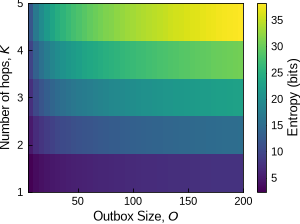

In [2]:
entropy_grid = np.zeros((len(K_vals), len(O_vals)))

for row, max_hops in enumerate(K_vals):
    for col, outbox_size in enumerate(O_vals):
        config = ExperimentConfig(max_hops=max_hops, mix_outbox_size=outbox_size)
        indicators = compute_indicators(config)
        entropy_grid[row, col] = indicators["anonymity"]["path_entropy_bits"]

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

im = ax.imshow(entropy_grid, aspect="auto", origin="lower", extent=[O_vals[0], O_vals[-1], K_vals[0], K_vals[-1]], cmap="viridis")
ax.set_xlabel("Outbox Size, $O$")
ax.set_ylabel("Number of hops, $K$")
ax.set_yticks(K_vals)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Entropy (bits)")

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/path_entropy_heatmap.pdf")
plt.show()

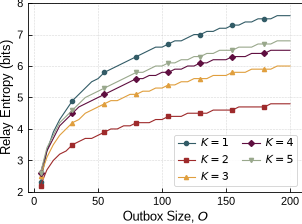

In [3]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

for idx, max_hops in enumerate(K_vals):
    relay_entropy = []
    for outbox_size in O_vals:
        config = ExperimentConfig(max_hops=max_hops, mix_outbox_size=outbox_size)
        indicators = compute_indicators(config)
        relay_entropy.append(indicators["anonymity"]["relay_entropy_bits"])

    ax.plot(
        O_vals, relay_entropy, marker=markers[idx], color=K_colors[idx], label=f"$K={max_hops}$", linewidth=0.8, markevery=5, markersize=3
    )

ax.set_xlabel("Outbox Size, $O$")
ax.set_ylabel("Relay Entropy (bits)")
ax.set_ylim(2, 8)
ax.set_yticks(range(2, 9))
ax.grid(**GRID_STYLE)

legend = ax.legend(loc="lower right", ncol=2)
legend.get_frame().set_facecolor((1, 1, 1, 1))

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/relay_entropy_lines.pdf")
plt.show()

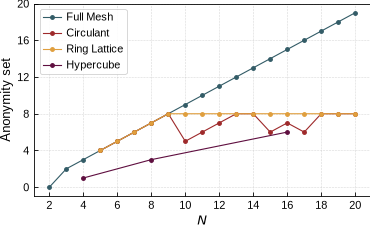

In [4]:
fig, ax = plt.subplots(figsize=(3.78, 2.36))

# Not every (topology, N) pair is valid, so I skip the ones that raise
for topo, label, color in zip(topo_types, topo_labels, colors):
    node_counts = []
    set_sizes = []

    for N in N_vals:
        try:
            config = ExperimentConfig(n_nodes=N, topology_type=topo, graph_degree=4, max_hops=2)
            indicators = compute_indicators(config)
            node_counts.append(N)
            set_sizes.append(indicators["anonymity"]["anonymity_set_size"])
        except Exception:
            pass

    ax.plot(node_counts, set_sizes, marker="o", label=label, color=color, linewidth=0.8, markersize=2.5)

ax.set_xlabel(r"$N$")
ax.set_ylabel("Anonymity set")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_yticks(range(0, 21, 4))
ax.grid(**GRID_STYLE)

legend = ax.legend()
legend.get_frame().set_facecolor((1, 1, 1, 1))

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/anonymity_set_by_topology.pdf")
plt.show()

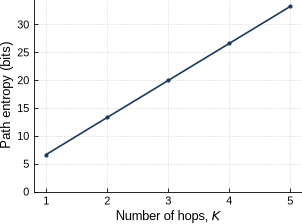

In [5]:
O_BASE = 100
hop_values = [1, 2, 3, 4, 5]

path_entropy_k = []
for k in hop_values:
    total_paths = sum(O_BASE**hops for hops in range(1, k + 1))
    path_entropy_k.append(np.log2(total_paths))

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

ax.plot(hop_values, path_entropy_k, color=navy, **LINE_STYLE, **MARKER_STYLE)
ax.set_xlabel("Number of hops, $K$")
ax.set_ylabel("Path entropy (bits)")
ax.set_xticks(hop_values)
ax.set_ylim(bottom=0)
ax.grid(**GRID_STYLE)

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/path_entropy_vs_k.pdf")
plt.show()